In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neural_network import MLPRegressor
import itertools

In [33]:
cell_cycle = pd.read_csv('/Users/mariahloehr/IICD/IICD/Data/cell_cycle_tidied.csv') 

In [6]:
import sys
sys.path.append("/Users/mariahloehr/IICD/IICD/feature_importance")

In [7]:
import locomp
from locomp import *
from locomp.MLmodels import *
from locomp.util_locomp import *
import itertools
import importlib
from sklearn.base import BaseEstimator, RegressorMixin, clone
import itertools
from functools import partial
import multiprocessing as mp
import re

import functions_case as il
import importlib

In [34]:
# Define features and target
X = cell_cycle.drop(columns=['phase', 'age', 'PHATE_1', 'PHATE_2'])  # Features
y = cell_cycle['age']  # Target: age

feature_names = X.columns.tolist()
feature_pairs = list(itertools.combinations(range(X.shape[1]), 2))
X = X.to_numpy()
y = y.to_numpy()

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=949
)

In [35]:
data = np.load("/Users/mariahloehr/IICD/IICD/LOCO/Ensembles/meta_ensemble.npz")

# Access arrays
predictions = data["predictions"]
mp_observations  = data["obs"]
mp_features  = data["feats"]

In [10]:
# Split predictions back
preds_rf, preds_xgb, preds_mlp = np.split(predictions, 3, axis=1)

# Do the same for observations and features (assuming same concatenation order)
obs_rf, obs_xgb, obs_mlp = np.split(mp_observations, 3, axis=1)
feats_rf, feats_xgb, feats_mlp = np.split(mp_features, 3, axis=1)

In [11]:
from mpl_toolkits.mplot3d import Axes3D

def plot_interaction_surface(X, Y, j1, j2, model, 
                             predictions, mp_observations, mp_features,
                             n_points=30):
      
    """
    Plot the 2D interaction surface f_{j,k}(x_j, x_k)

    Parameters
    ----------
    model : fitted model or prediction function
        Must implement predict_proba or predict.
    X : ndarray of shape (n, d)
        Data matrix.
    j, k : int
        Feature indices to analyze.
    mask_fn : function
        Function that takes (X, mask) and returns predictions under iLOCO masking.
        Should mimic your masked_mean_probs logic.
    grid_points : int
        Number of points along each axis for grid.
    """

    # Make grid in plane (x_j1, x_j2)
    x1_vals = np.linspace(X[:, j1].min(), X[:, j1].max(), n_points)
    x2_vals = np.linspace(X[:, j2].min(), X[:, j2].max(), n_points)
    Xgrid1, Xgrid2 = np.meshgrid(x1_vals, x2_vals)

    # Fix other features at mean
    Xref = np.mean(X, axis=0)
    grid_points = []
    for a, b in zip(Xgrid1.ravel(), Xgrid2.ravel()):
        row = Xref.copy()
        row[j1] = a
        row[j2] = b
        grid_points.append(row)
    grid_points = np.array(grid_points)

    # Ensemble predictions on grid
    #preds_grid = model.predict(grid_points)  # shape (n_points^2, B, K) ideally
    preds_grid = il.Ensemble(model).predict(grid_points)

    # Use iLOCO residuals on grid
    r12, r1, r2, r = il.computeDeltaCap(
        Y=np.zeros(len(grid_points)), # dummy Y (we only need preds)
        j1=j1, j2=j2,
        predictions=preds_grid,
        mp_observations=mp_observations,
        mp_features=mp_features
    )
    delta = (r1 + r2 - r12 - r).reshape(n_points, n_points)

    # Plot surface
    fig = plt.figure(figsize=(8,6))
    ax = fig.add_subplot(111, projection="3d")
    ax.plot_surface(Xgrid1, Xgrid2, delta, cmap="viridis")
    ax.set_xlabel(f"Feature {j1}")
    ax.set_ylabel(f"Feature {j2}")
    ax.set_zlabel("Interaction contribution")
    plt.show()


In [12]:
from scipy.interpolate import griddata

def plot_interaction_surface_from_saved(X, Y, predictions, mp_observations, mp_features, 
                                        j1, j2, n_points=40):
    """
    Plot interaction surface using saved ensemble predictions (n, B).
    """

    # ---- Compute residual deltas (using saved preds) ----
    r12, r1, r2, r = il.computeDeltaCap(
        Y=Y, 
        j1=j1, j2=j2, 
        predictions=predictions,
        mp_observations=mp_observations,
        mp_features=mp_features
    )
    delta = r1 + r2 - r12 - r   # (n,) values at each observation

    # ---- Interpolation grid ----
    x1_vals = np.linspace(X[:, j1].min(), X[:, j1].max(), n_points)
    x2_vals = np.linspace(X[:, j2].min(), X[:, j2].max(), n_points)
    Xgrid1, Xgrid2 = np.meshgrid(x1_vals, x2_vals)

    # interpolate scattered (X[:,j1], X[:,j2], delta) onto grid
    Z = griddata(
        points = (X[:, j1], X[:, j2]),
        values = delta,
        xi = (Xgrid1, Xgrid2),
        method = "linear"
    )

    # ---- Plot ----
    fig = plt.figure(figsize=(8,6))
    ax = fig.add_subplot(111, projection="3d")
    surf = ax.plot_surface(Xgrid1, Xgrid2, Z, cmap="viridis", alpha=0.8)
    #ax.set_xlabel(f"Feature {j1}")
    #ax.set_ylabel(f"Feature {j2}")
    ax.set_xlabel(cell_cycle.columns[j1])
    ax.set_ylabel(cell_cycle.columns[j2])
    ax.set_zlabel("Interaction contribution")
    fig.colorbar(surf, shrink=0.5, aspect=8, label="delta")
    plt.show()


In [14]:
def DecisionTreeReg(X,Y,X1):
    tree = DecisionTreeRegressor(max_depth = 20, 
                                 max_features=150,
                                 random_state=949
                                 ).fit(X,Y)
    return tree.predict(X1)

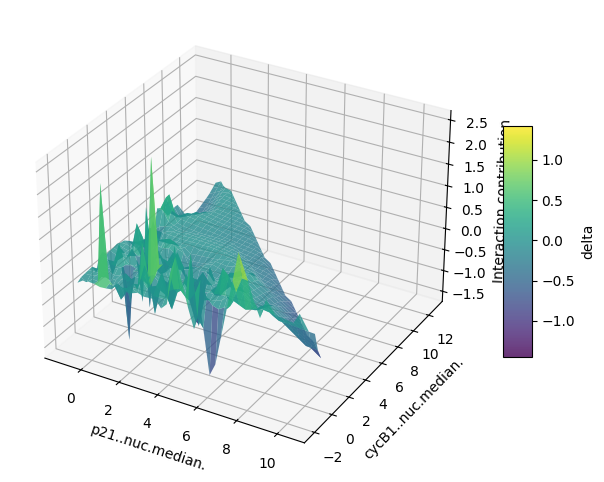

In [15]:
plot_interaction_surface_from_saved(X, y, 
                                    predictions = preds_rf, mp_observations = obs_rf, mp_features = feats_rf, 
                                        j1 = 3, j2 = 18, n_points=40)

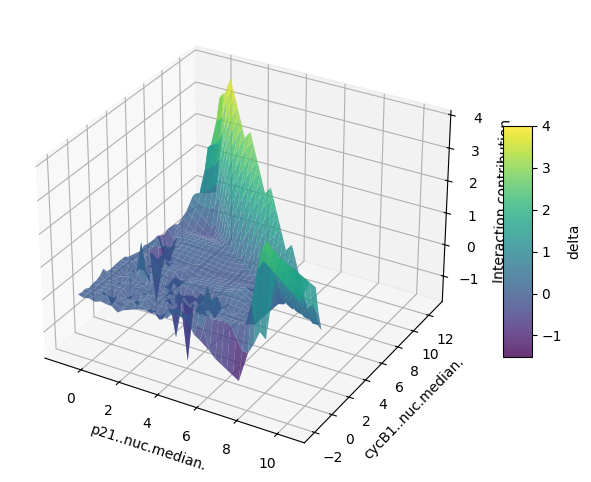

In [16]:
plot_interaction_surface_from_saved(X, y, 
                                    predictions = preds_mlp, mp_observations = obs_mlp, mp_features = feats_mlp, 
                                        j1 = 3, j2 = 18, n_points=40)

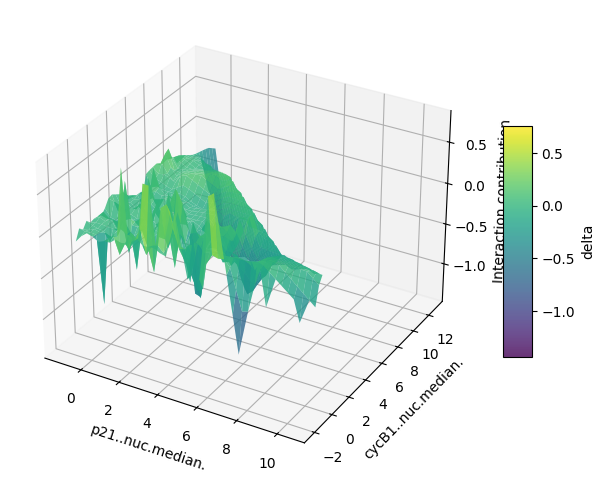

In [17]:
plot_interaction_surface_from_saved(X, y, 
                                    predictions = preds_xgb, mp_observations = obs_xgb, mp_features = feats_xgb, 
                                        j1 = 3, j2 = 18, n_points=40)

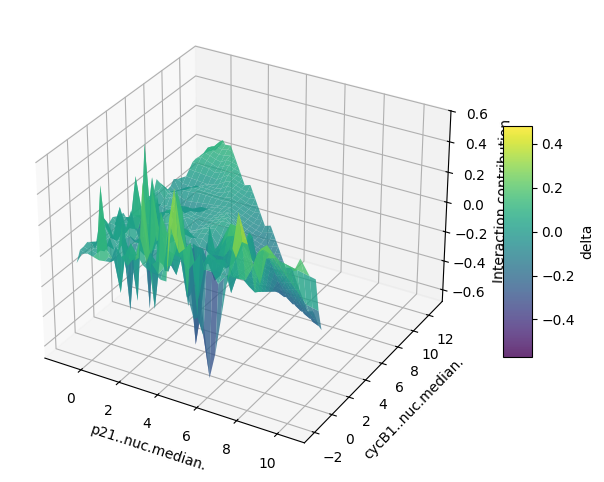

In [18]:
plot_interaction_surface_from_saved(X, y, 
                                    predictions, mp_observations, mp_features, 
                                        j1 = 3, j2 = 18, n_points=40)

THIN PLATE SPLINE

In [31]:
from scipy.interpolate import Rbf

def plot_interaction_surface_from_saved_tps(X, Y, predictions, mp_observations, mp_features, 
                                            j1, j2, n_points=40):
    """
    Plot smoothed interaction surface using saved ensemble predictions (n, B)
    with thin plate spline interpolation.
    """

    # ---- Compute residual deltas (using saved preds) ----
    r12, r1, r2, r = il.computeDeltaCap(
        Y=Y, 
        j1=j1, j2=j2, 
        predictions=predictions,
        mp_observations=mp_observations,
        mp_features=mp_features
    )
    delta = r1 + r2 - r12 - r   # (n,) interaction values at each observation

    # ---- Interpolation grid ----
    x1_vals = np.linspace(X[:, j1].min(), X[:, j1].max(), n_points)
    x2_vals = np.linspace(X[:, j2].min(), X[:, j2].max(), n_points)
    Xgrid1, Xgrid2 = np.meshgrid(x1_vals, x2_vals)

    # ---- Thin plate spline smoothing ----
    tps = Rbf(X[:, j1], X[:, j2], delta, function="thin_plate")
    Z = tps(Xgrid1, Xgrid2)

    # ---- Plot 3D surface ----
    fig = plt.figure(figsize=(8,6))
    ax = fig.add_subplot(111, projection="3d")
    surf = ax.plot_surface(Xgrid1, Xgrid2, Z, cmap="viridis", alpha=0.8)

    # Use column names if available, otherwise use index
    try:
        ax.set_xlabel(cell_cycle.columns[j1])
        ax.set_ylabel(cell_cycle.columns[j2])
    except NameError:
        ax.set_xlabel(f"Feature {j1}")
        ax.set_ylabel(f"Feature {j2}")

    ax.set_zlabel("Interaction contribution")
    fig.colorbar(surf, shrink=0.5, aspect=8, label="delta")
    plt.show()

    return Z


/Users/mariahloehr/IICD/IICD/sklearn-env/lib/python3.12/site-packages/scipy/interpolate/_rbf.py:268: LinAlgWarning: Ill-conditioned matrix (rcond=1.13172e-25): result may not be accurate.
  self.nodes = linalg.solve(self.A, self.di)


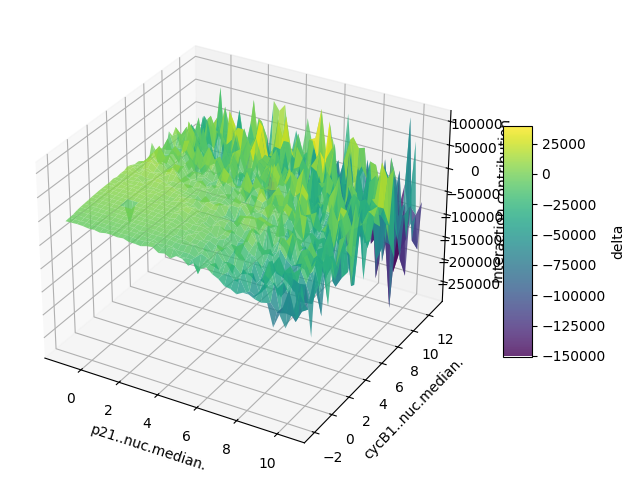

array([[  -5984.,   -5504.,   -4800., ...,  -92160.,  -61440.,  -65536.],
       [  -4832.,   -4480.,   -4736., ...,  -19456.,  -69632.,       0.],
       [  -4272.,   -2752.,   -3840., ...,  -80896.,  -24576.,  -49152.],
       ...,
       [-143360.,  -45056.,  -36864., ..., -151552.,  -65536.,  -81920.],
       [-110592.,    2048.,  -16384., ...,  114688., -147456., -163840.],
       [ -65536.,  -24576.,  -57344., ..., -126976.,  -98304.,  -65536.]],
      shape=(40, 40))

In [36]:
plot_interaction_surface_from_saved_tps(X, y, 
                                    predictions = preds_rf, mp_observations = obs_rf, mp_features = feats_rf, 
                                        j1 = 3, j2 = 18, n_points=40)

CANCER DATA

In [38]:
# Load data
cancer = pd.read_csv("/Users/mariahloehr/IICD/IICD/Cancer treatment/T47D.csv")

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Separate features and target
X_cancer = cancer.drop(columns=['phase', 'Metadata_well'])
y_cancer = le.fit_transform(cancer['Metadata_well'])

feature_names = X_cancer.columns.tolist()
feature_pairs = list(itertools.combinations(range(X_cancer.shape[1]), 2))
X_cancer = X_cancer.to_numpy()
#y = y.to_numpy()

In [39]:
data = np.load("/Users/mariahloehr/IICD/IICD/Cancer treatment/LOCO/encoded_rf.npz")

# Access arrays
preds_cancer = data["predictions"]
obs_cancer  = data["obs"]
feats_cancer  = data["feats"]

In [40]:
preds_cancer = np.transpose(preds_cancer, (1, 0, 2))

obs_cancer = obs_cancer.T  # → (n, B)

feats_cancer = feats_cancer.T  # → (n, F)

In [25]:
from scipy.interpolate import griddata

def plot_interaction_surface_from_saved_class(X, Y, predictions, mp_observations, mp_features, 
                                        j1, j2, n_points=40):
    """
    Plot interaction surface using saved ensemble predictions (n, B).
    """

    # ---- Compute residual deltas (using saved preds) ----
    r12, r1, r2, r = il.computeDeltaCap_xent(
        Y=Y, 
        j1=j1, j2=j2, 
        predictions=predictions,
        mp_observations=mp_observations,
        mp_features=mp_features
    )
    delta = r1 + r2 - r12 - r   # (n,) values at each observation

    # ---- Interpolation grid ----
    x1_vals = np.linspace(X[:, j1].min(), X[:, j1].max(), n_points)
    x2_vals = np.linspace(X[:, j2].min(), X[:, j2].max(), n_points)
    Xgrid1, Xgrid2 = np.meshgrid(x1_vals, x2_vals)

    # interpolate scattered (X[:,j1], X[:,j2], delta) onto grid
    Z = griddata(
        points = (X[:, j1], X[:, j2]),
        values = delta,
        xi = (Xgrid1, Xgrid2),
        method = "linear"
    )

    # ---- Plot ----
    fig = plt.figure(figsize=(8,6))
    ax = fig.add_subplot(111, projection="3d")
    surf = ax.plot_surface(Xgrid1, Xgrid2, Z, cmap="viridis", alpha=0.8)
    #ax.set_xlabel(f"Feature {j1}")
    #ax.set_ylabel(f"Feature {j2}")
    ax.set_xlabel(cancer.columns[j1])
    ax.set_ylabel(cancer.columns[j2])
    ax.set_zlabel("Interaction contribution")
    fig.colorbar(surf, shrink=0.5, aspect=8, label="delta")
    plt.show()


In [27]:
cancer.columns.get_loc("Intensity_MedianIntensity_pRB")

18

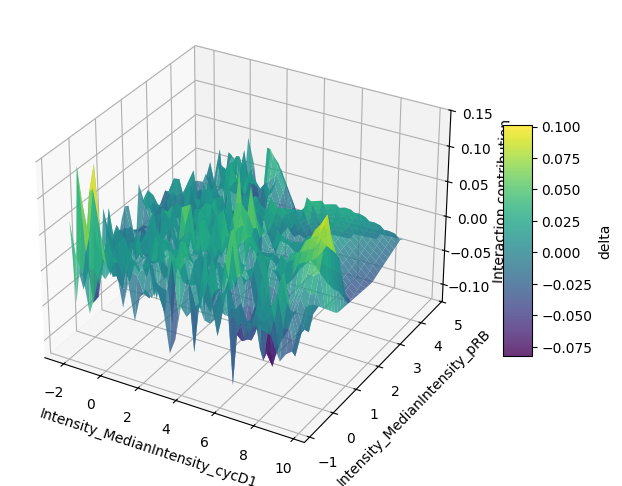

In [41]:
plot_interaction_surface_from_saved_class(X_cancer, y_cancer, preds_cancer, obs_cancer, feats_cancer, 
                                        j1 = 15, j2 = 18, n_points=40)